In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import factorial,sqrt,pi
np.random.seed(42)


Bernouli sample mean (approx p): 0.2992
Bernouli sample var (approx p(1-P)): 0.20967935999999995

Normal sample mean(approx mu): 2.000862490752545

Normal sample var(approx sigma^2): 2.234987631938979


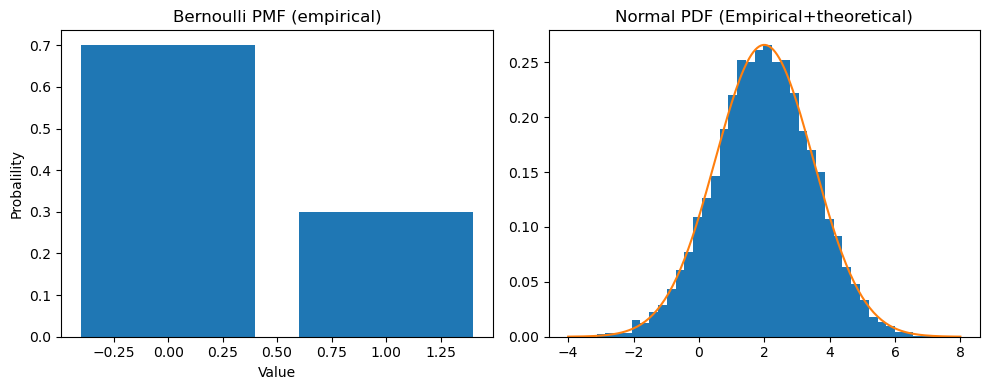

In [9]:
p=0.3
n_samples=10000
bern=np.random.binomial(1,p,size=n_samples)
print('Bernouli sample mean (approx p):',bern.mean())
print('Bernouli sample var (approx p(1-P)):',bern.var())
mu,sigma=2.0,1.5
norm_samples=np.random.normal(mu,sigma,size=n_samples)
print('\nNormal sample mean(approx mu):',norm_samples.mean())
print('\nNormal sample var(approx sigma^2):',norm_samples.var())
fig,axes=plt.subplots(1,2,figsize=(10,4))
vals,counts=np.unique(bern,return_counts=True)
axes[0].bar(vals,counts/len(bern))
axes[0].set_title('Bernoulli PMF (empirical)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Probalility')                  

axes[1].hist(norm_samples,bins=40,density=True)
x=np.linspace(mu-4*sigma,mu+4*sigma,200)
axes[1].plot(x,stats.norm.pdf(x,mu,sigma))
axes[1].set_title('Normal PDF (Empirical+theoretical)')
plt.tight_layout()
plt.show()

Binomial Theroetical mean,var: 4.0 2.4
Poisson Theroetical mean,var: 3.0 3.0


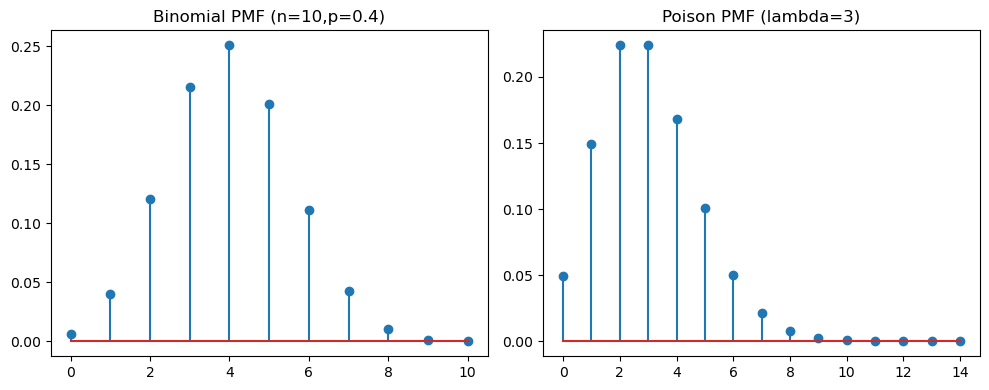

In [14]:
#Common DD
n,p=10,0.4
k=np.arange(0,n+1)
pmf_binom=stats.binom.pmf(k,n,p)
print('Binomial Theroetical mean,var:',
stats.binom.mean(n,p),
stats.binom.var(n,p))

lam=3.0
k_p=np.arange(0,15)
pmf_pois=stats.poisson.pmf(k_p,lam)
print('Poisson Theroetical mean,var:',
     stats.poisson.mean(lam),
     stats.poisson.var(lam))

#PLot PMFS
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].stem(k,pmf_binom)
ax[0].set_title('Binomial PMF (n=10,p=0.4)')
ax[1].stem(k_p,pmf_pois)
ax[1].set_title('Poison PMF (lambda=3)')
plt.tight_layout()
plt.show()

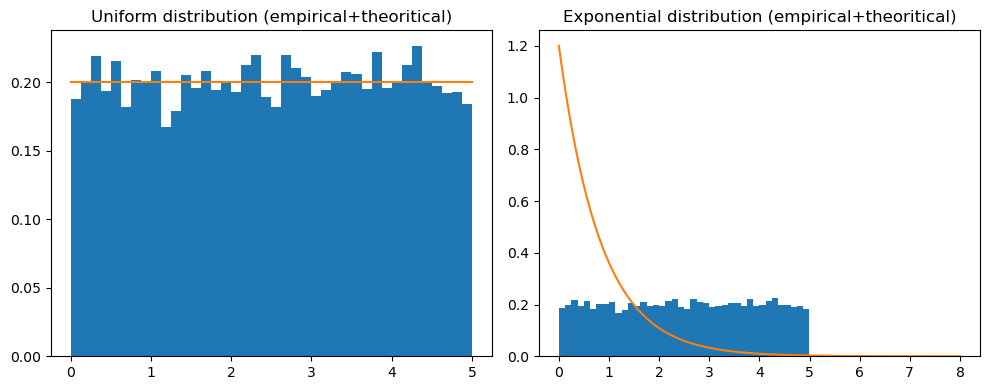

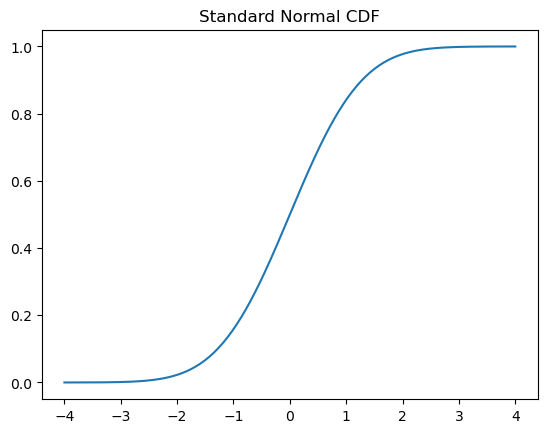

In [6]:
# Uniform
a,b=0,5
uni_samps=np.random.uniform(a,b,size=10000)
x=np.linspace(a,b,200)

# Exponential
lam=1.2
exp_samps=np.random.exponential(1/lam, size=10000)
x_exp=np.linspace(0,8,200)
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].hist(uni_samps,bins=40,density=True)
ax[0].plot(x,stats.uniform.pdf(x,a,b-a))
ax[0].set_title('Uniform distribution (empirical+theoritical)')
ax[1].hist(uni_samps,bins=40,density=True)
ax[1].plot(x_exp,stats.expon.pdf(x_exp,scale=1/lam))
ax[1].set_title('Exponential distribution (empirical+theoritical)')
plt.tight_layout()
plt.show()
#Normal Shown prev
xs=np.linspace(-4,4,200)
plt.plot(xs,stats.norm.cdf(xs))
plt.title('Standard Normal CDF')
plt.show()

Empirical Cov: 0.5737860925977283
Empirical Cor: 0.5810766683857452


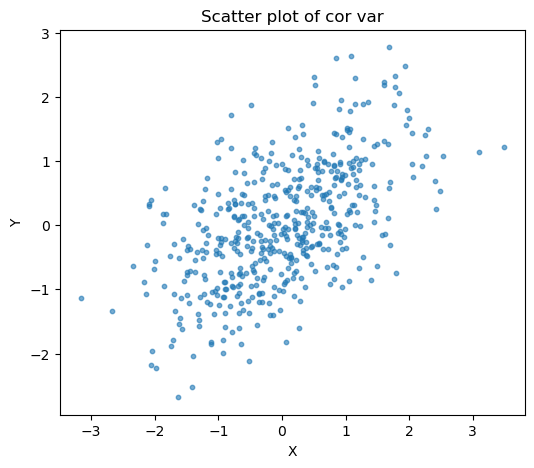

In [18]:
mean=[0,0]
cov=[[1.0,0.6],[0.6,1.0]]
samples=np.random.multivariate_normal(mean,cov,size=5000)
x=samples[:,0]
y=samples[:,1]
print('Empirical Cov:',np.cov(x,y)[0,1])
print('Empirical Cor:',np.corrcoef(x,y)[0,1])

#SCatter PLot
plt.figure(figsize=(6,5))
plt.scatter(x[:500],y[:500],s=10,alpha=0.6)
plt.title('Scatter plot of cor var')
plt.xlabel('X');
plt.ylabel('Y');
plt.show()

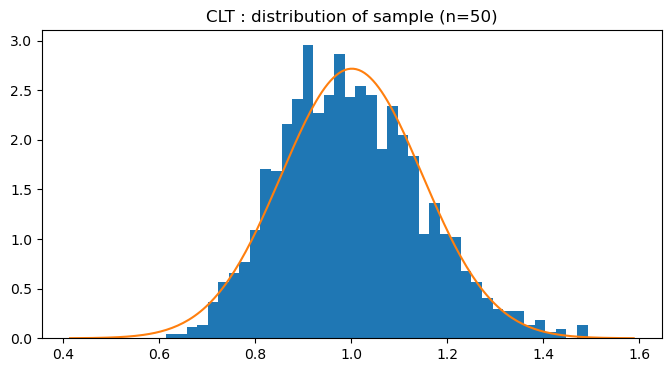

Sample means mean: 1.0013999490052787 std 0.14682282402763094


In [21]:
#CLT demonstration
pop=np.random.exponential(scale=1.0,size=200000)
sample_size=50
n_trials=2000
means=[np.mean(np.random.choice(pop,sample_size)) for _ in range(n_trials)]
plt.figure(figsize=(8,4))
plt.hist(means,bins=40,density=True)

mu_hat=np.mean(means)
sigma_hat=np.std(means)
x=np.linspace(mu_hat-4*sigma_hat,mu_hat+4*sigma_hat,200)
plt.plot(x,stats.norm.pdf(x,mu_hat,sigma_hat))
plt.title(f'CLT : distribution of sample (n={sample_size})')
plt.show()
print('Sample means mean:',mu_hat,'std',sigma_hat)